# Analysis of cross section sampling using SANDY

In this section, we perform a complete uncertainty analysis of U‑234 nuclear data using a set of **20 random ENDF‑6 files** generated with SANDY.

For each random ENDF file:

- we load the corresponding PENDF (pointwise ENDF) for cross sections
- we extract cross‑section samples for multiple MT reactions
- we compute sample means and sample standard deviations
- we compare the sample statistics with the expected uncertainty from the official ENDF-6 covariance (ERRORR)
- we compute bootstrap confidence intervals for the sample standard deviation
- we visualize uncertainty behavior across energy regions

> This provides both visual and statistical validation that the stochastic sampling matches the nuclear data covariance information.

## Import packages

In [1]:
import sandy

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


## Helper function

In [3]:
def get_confidence_intervals(df, n_resamples=100, confidence_level=0.95):
    import numpy as np
    from scipy.stats import bootstrap
    
    # xss_[mt] shape: (16795, 50)
    data = (df.T,)  # transpose so shape is (50, 16795)
                           # bootstrap expects samples along axis=0
    
    # Define a statistic function that works on 2D input
    # It should return an array of stds along axis=0 (over samples)
    def row_std(arr, axis=0):
        return np.std(arr, axis=axis)
    
    # Call bootstrap
    res = bootstrap(
        data,
        statistic=row_std,
        confidence_level=confidence_level,
        n_resamples=n_resamples,
        method='percentile',
        vectorized=True
    )
    
    # Extract confidence intervals
    ci_lower, ci_upper = res.confidence_interval.low, res.confidence_interval.high
    return ci_lower, ci_upper

# Loading Random ENDF6 and PENDF Files

We begin by loading 20 random PENDF files, containing perturbed pointwise cross sections

The random files were produced running `sandy` from the command line interface with:

```bash
python -m sandy.samping U234.dat --samples 20 --processes 1 --acer --temperature 293.15
```

We collect cross‑section samples from perturbed files:

 - MT=2 → elastic scattering
 - MT=4 → inelastic scattering
 - MT=18 → fission
 - MT=102 → radiative capture

In [4]:
sample_size = 20

folder = Path("pregenerated_samples")

# LOAD ENDF-6 AND PENDF PERTURBED FILES
pendf_tapes = {i: sandy.Endf6.from_file(folder / f"92234_{i}.pendf") for i in range(sample_size)}

# COLLECT SPECIFIC CROSS SECTIONS (MT NUMBERS)
xss = {k: sandy.Xs.from_endf6(v) for k, v in pendf_tapes.items()}
xss_ = {}
for mt in [2, 4, 18, 102]:
    xss_[mt] = pd.DataFrame({k: v.data[9225, mt] for k, v in xss.items()})

# Plotting the Sampled Cross Sections

We can draw all 20 sampled cross sections for a selected reaction MT and visualize the variability.

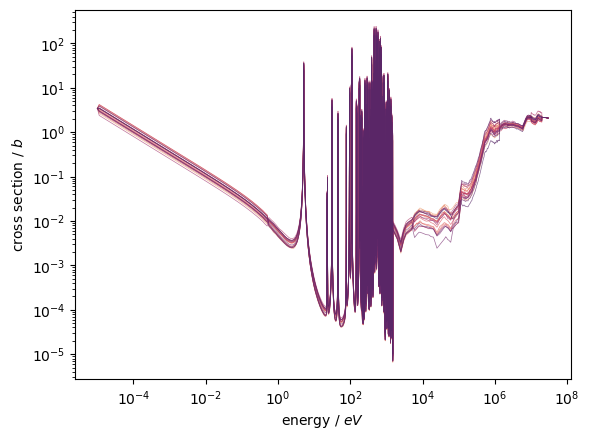

In [5]:
mt = 18

colors = sns.color_palette("flare", n_colors=len(xss_[mt].columns))
ax = xss_[mt].plot(logx=True, logy=True, alpha=.7, lw=.5, color=colors)
ax.legend().remove()

ax.set(xlabel="energy / $eV$", ylabel="cross section / $b$");

# Mean and Standard Deviation of Cross‑Section Samples

For a selected MT, we compute:

- **sample mean**
- **sample standard deviation**

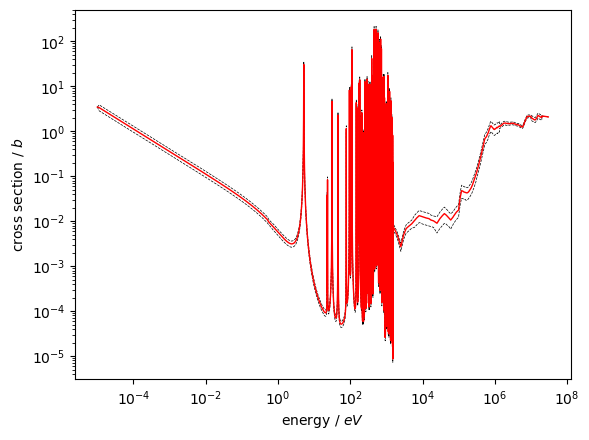

In [6]:
mt = 18

mean = xss_[mt].mean(axis=1)
std = xss_[mt].std(axis=1)

ax = (mean + std).plot(alpha=1, lw=.5, ls='--', color="k")
(mean - std).plot(alpha=1, lw=.5, ls='--', color="k", ax=ax)
mean.plot(logx=True, logy=True, alpha=1, lw=1, color="r", ax=ax)
ax.set(xlabel="energy / $eV$", ylabel="cross section / $b$");

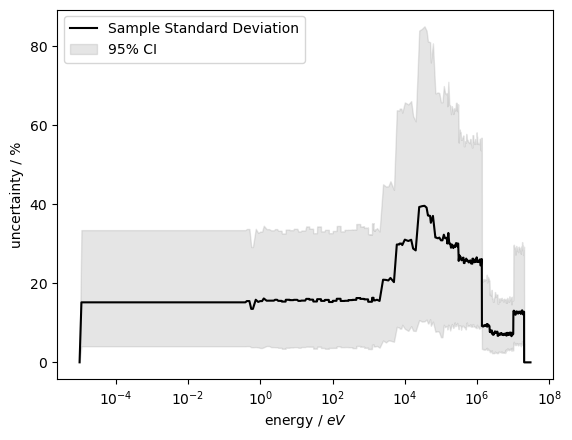

In [10]:
mt = 18

rstd = std / mean * 100
ax = rstd.plot(logx=True, logy=False, color="k", label="Sample Standard Deviation")
ax.set(xlabel="energy / $eV$", ylabel="uncertainty / %");

# Compute and plot the upper and lower boundaries of the confidence interval
ci_lower, ci_upper = get_confidence_intervals(xss_[mt], confidence_level=0.95)
lower = (std - ci_lower) / mean * 100
upper = (std + ci_upper) / mean * 100
plt.fill_between(mean.index, lower, upper, color='gray', alpha=0.2, label=f'95% CI')
ax.legend();

# Comparison with ENDF-6 Covariance (ERRORR)

We load the ERRORR covariance block from the reference U-234 ENDF-6 file `U234.dat` and extract the covariance matrix for cross sections.

In [11]:
tape = sandy.Endf6.from_file("U234.dat")

err = tape.get_errorr()
cov33 = err["errorr33"].get_cov()

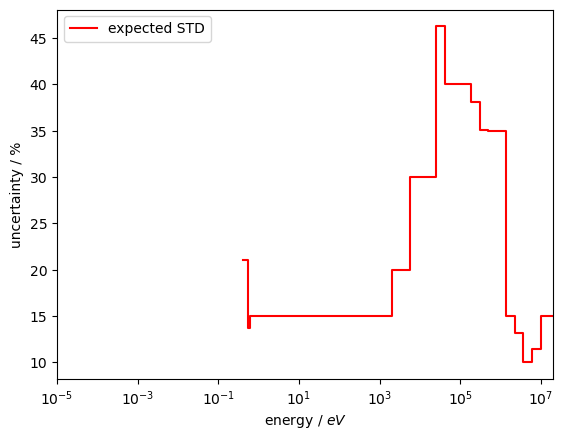

In [21]:
mt = 18

std33 = cov33.get_std().multiply(100).reset_index().query("MT==@mt")
std33["ERIGHT"] = [x.right for x in std33.E]
ax = std33.plot(x="ERIGHT", y="STD", ds="steps-pre", label="expected STD", color="red", logx=True)
ax.set(xlabel="energy / $eV$", ylabel="uncertainty / %", xlim=(1e-5, 2e7));

Compare the sample standard deviation against the expected one.

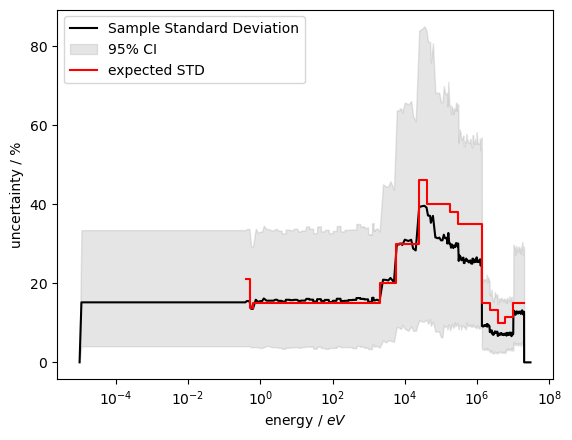

In [25]:
# SAMPLE  ESTIMATE
ax = rstd.plot(logx=True, logy=False, color="k", label="Sample Standard Deviation")
ax.fill_between(mean.index, lower, upper, color='gray', alpha=0.2, label=f'95% CI')

# EXPECTED
std33.plot(x="ERIGHT", y="STD", ds="steps-pre", label="expected STD", color="red", logx=True, ax=ax)

ax.set(xlabel="energy / $eV$", ylabel="uncertainty / %")
ax.legend();